$$\textbf{\Large Amirreza Taheri}$$
$$\textbf{\LARGE Neural Networks and Deep Learning - Assignment 3}$$

## Question 1 - Forecasting the Value of Oil

>   
>   One of the most common applications of memory-based neural networks is time-series prediction.
>   In this question you will learn how to forecast the **raw value of crude oil** using four different methods.


#### 1-1 Dataset and Preparation (20 points)


>   Download the dataset for this question by selecting the **CL = F** symbol on [Yahoo Finance](https://finance.yahoo.com/quote/CL%3DF) for the years 2010 to present, and among the recorded columns select **Adj Close** as the main feature.
>   
>   * On some days no data were recorded; those rows are regarded as **null**.
>   * In addition to the existing **null** rows, randomly delete some other rows.
>   * Then implement substitution methods, fill in the data, and complete the dataset.
>   * In this research the data are treated as a time series, so we split them with the **Temporal Split** method, which guarantees that the validation and test data come *after* the training data in time (and not scattered through the series).

#### What is a Temporal Split?

>   A standard method for partitioning time-series data into training and test sections **while preserving chronological order**.
>   Unlike random splits that may leak future information, a Temporal Split first feeds *older* data to the model for training and then evaluates on *newer* data, stopping information leakage and better matching real-world forecasting tasks. For more information see **[this link](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html)**.
>   
>   If the validation window is small the **Rolling Forecast Origin** technique can be used to evaluate the model across different time spans. Finally, all data are normalised.
>   


#### What is a Rolling Forecast Origin?

   
>   In this approach the model is updated step-by-step with new data, and at every forecasting step the origin moves forward, repeating the process.
>   This results in a more realistic evaluation than a fixed train/test split and resembles real-world conditions in which models continually receive fresh data. The method allows finer analysis of the model’s behaviour when facing consecutive data and temporal changes. For more information see **[this link](https://otexts.com/fpp3/tscv.html)** or **[this link](https://openforecast.org/adam/rollingOrigin.html)**.


#### 1-2 Model Implementation (45 points)

>   In the referenced article four time-series forecasting models—**RNN, GRU, LSTM, and Bi-LSTM**—were implemented while using Mean Square Error as the loss function. Train these four models with **exactly** the hyper-parameters given in **Table 4** and report all requested items.
>   
>   ##### Table 4 - Hyper-parameters of LSTM, GRU, and Bi-LSTM modelling
>   
>   | Hyper-parameter | Value                            |
>   | --------------- | -------------------------------- |
>   | Learning Rate   | 0.0010                           |
>   | Batch Size      | 100                              |
>   | Optimizer       | Adam                             |
>   | Epochs          | 50                               |
>   | Units           | 512 (LSTM & GRU); 1024 (Bi-LSTM) |
>   
>   * For each of the three requested models, plot the predicted values **together with** the real values (15 pts).
>   * First give brief definitions of **MAPE, MAE, RMSE, and R-Squared**, then report the numbers and **analyse and compare** them.


#### 1-3 ARIMA (bonus 10 points)


>   In this part you will become familiar with the classical models **ARIMA** and **SARIMA**; first state their differences.
>   
>   * Explain the mathematical concept of the ARIMA model together with all its parameters.
>   * Find and report the *optimised* parameters for the model.
>   * Provide a table similar to Table 5 in the article and compare your results.

## Answer 1

### Prerequisits

In [1]:
# System and Warnings
import warnings
warnings.warn = lambda *args, **kwargs: None


# Core Data Handling
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Yahoo Finance Data
import yfinance as yf

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Sklearn Utilities
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Statsmodels for Classical Time Series
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)


### Functions

In [2]:
# Performance metrics calculation function
def calculate_metrics(y_true, y_pred):
    # Convert back to original scale
    y_true_inv = scaler.inverse_transform(y_true.reshape(-1, 1))
    y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1))
    
    # Calculate metrics
    mse = mean_squared_error(y_true_inv, y_pred_inv)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_inv, y_pred_inv)
    r2 = r2_score(y_true_inv, y_pred_inv)
    mape = np.mean(np.abs((y_true_inv - y_pred_inv) / y_true_inv)) * 100
    
    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        '$R^2$': r2,
        'MAPE': mape
    }

In [3]:
# Model training and evaluation function
def train_and_evaluate_model(model, model_name):
    # Early stopping to prevent overfitting
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    
    # Train the model
    print(f"\nTraining {model_name} model...")
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Plot training history
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.close()
    
    # Predict on test data
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    metrics = calculate_metrics(y_test, y_pred)
    print(f"\n{model_name} Performance Metrics:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
    
    # Plot actual vs predicted values
    test_dates = df_filled.index[train_size + val_size + seq_length:].values
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
    y_pred_inv = scaler.inverse_transform(y_pred)
    
    plt.figure(figsize=(12, 6))
    plt.plot(test_dates, y_test_inv, label='Actual', color='blue')
    plt.plot(test_dates, y_pred_inv, label='Predicted', color='red', linestyle='--')
    plt.title(f'{model_name} - Actual vs Predicted Oil Prices')
    plt.xlabel('Date')
    plt.ylabel('Adjusted Close Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    plt.close()
    
    return metrics, y_test_inv, y_pred_inv

In [4]:
# Create sequences for time series forecasting
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

In [5]:
def train_evaluate_visualize(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test, 
                             scaler, df_filled, train_size, val_size, seq_length):
    # Early stopping to halt training if validation loss stops improving
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    # Train the model
    print(f"\nTraining {model_name}...")
    history = model.fit(X_train, y_train, epochs=50, batch_size=100, 
                        validation_data=(X_val, y_val), callbacks=[early_stop], verbose=0, shuffle=False)
    
    # Predict on test set
    y_pred = model.predict(X_test, verbose=0)
    
    # Inverse transform predictions and actual values to original scale
    y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))
    y_pred_orig = scaler.inverse_transform(y_pred.reshape(-1, 1))
    
    # Compute performance metrics
    mse = mean_squared_error(y_test_orig, y_pred_orig)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_orig, y_pred_orig)
    mape = np.mean(np.abs((y_test_orig - y_pred_orig) / y_test_orig)) * 100
    r2 = r2_score(y_test_orig, y_pred_orig)
    
    metrics = {'Model': model_name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, '$R^2$': r2}
    
    # Plot 1: Actual vs Predicted Values
    test_dates = df_filled.index[train_size + val_size + seq_length: 
                                 train_size + val_size + seq_length + len(y_test)]
    plt.figure(figsize=(12, 6))
    plt.plot(test_dates, y_test_orig, label='Actual', color='blue', linewidth=2)
    plt.plot(test_dates, y_pred_orig, label='Predicted', color='red', linestyle='--', linewidth=2)
    plt.title(f'{model_name}: Actual vs Predicted Oil Prices', fontsize=16, pad=10)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price (USD)', fontsize=12)
    plt.legend(loc='upper left', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Plot 2: Training and Validation Loss History
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss', color='green', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linestyle='--', linewidth=2)
    plt.title(f'{model_name}: Training and Validation Loss', fontsize=16, pad=10)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (MSE)', fontsize=12)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    return metrics, y_pred_orig, history

In [6]:
# Helper Functions 
def adf_test(series):
    """Augmented Dickey-Fuller stationarity test"""
    result = adfuller(series.dropna(), autolag='AIC')
    output = pd.Series(result[:4], index=['Test Statistic','p-value','#Lags Used','Observations'])
    for k, v in result[4].items(): output[f'Critical Value ({k})'] = v
    print(output)
    return result[1] <= 0.05  # stationary if p <= 0.05


def evaluate_forecast(true, pred):
    """Compute performance metrics"""
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true, pred)
    r2 = r2_score(true, pred)
    mape = np.mean(np.abs((true - pred) / true)) * 100
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

In [7]:
# Forecasting Functions 
def forecast_arima(series, train_size):
    # Split into train/test
    train = series.iloc[:train_size]
    test = series.iloc[train_size:]

    # Stationarity
    print("ADF test on training data:")
    d = 0 if adf_test(train) else 1
    print(f"Selected d = {d}\n")

    # Grid search for p, q
    best_aic, best_order = np.inf, None
    for p in range(0, 5):
        for q in range(0, 5):
            try:
                model = ARIMA(train, order=(p, d, q)).fit()
                if model.aic < best_aic:
                    best_aic, best_order = model.aic, (p, d, q)
            except:
                continue
    print(f"Best ARIMA order: {best_order} (AIC={best_aic:.1f})\n")

    # Fit final ARIMA
    final_model = ARIMA(train, order=best_order).fit()
    forecast = final_model.forecast(steps=len(test))
    metrics = evaluate_forecast(test.values, forecast.values)
    return metrics, test.index, test.values, forecast.values

### Answer 1.1

Use the `yfinance` library to download daily data starting from January 1, 2010, up today and extract the **Adjusted Close** price, which adjusts for splits and dividends to provide a consistent price series.

In [8]:
# Dataset and Preparation
# Download crude oil futures data
print("Downloading crude oil futures data from Yahoo Finance...")
data = yf.download(
    tickers="CL=F",  # WTI crude oil futures
    start="2010-01-01",
    auto_adjust=False,
    progress=False
)

# Extract 'Adjusted Close' column into a new DataFrame
df = data[['Adj Close']].copy()
print(f"Downloaded {len(df)} days of data")

# Show basic info and a sample of the raw data
print("\nDataset Info:")
print(df.info())
print("\nFirst 5 rows of the downloaded data:")
display(df.head())

Downloaded 3861 days of data

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3861 entries, 2010-01-04 to 2025-05-09
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, CL=F)  3861 non-null   float64
dtypes: float64(1)
memory usage: 60.3 KB
None

First 5 rows of the downloaded data:


Price,Adj Close
Ticker,CL=F
Date,
2010-01-04,81.510002
2010-01-05,81.769997
2010-01-06,83.180000
2010-01-07,82.660004
2010-01-08,82.750000


In this part, I do the beklow tasks:

- Check for existing missing values (e.g., from non-trading days).  
- Randomly introduce additional missing values (5% of rows) to mimic real-world imperfections.  
- Fill all gaps using linear interpolation to maintain the time-series trend.

**Linear Interpolation:**

It estimates missing values as:
  $$
  x_t = x_{t-1} + \frac{t - (t-1)}{(t+1) - (t-1)} \cdot (x_{t+1} - x_{t-1})
  $$

This assumes a smooth trends, suitable for high frquency financial data with small gaps  where prices change gradually.

  - **Forward Fill:** $x_t = x_{t-1}$, risking bias.
  - **Backward Fill:** $x_t = x_{t+1}$, similarly limited.
  - **Polynomial:** Fits a polynomial of a specified degree (e.g., quadratic) through known points to estimate missing values.
  - **Spline:** Fits piecewise cubic polynomials between points, ensuring smoothness (continuous first and second derivatives).
  - **Nearest Neighbor:** Fills missing values with the nearest available value, either from the previous (forward fill) or next (backward fill) data point. By extending this concept we get K-Nearest-Neoghbor interpolation approach.
  - **Time Interpolation:** Interpolates based on the time index, similar to linear interpolation but explicitly using timestamp differences. Essentially is equivalent to linear interpolation for daily data with regular spacing.

In [9]:
# Check initial missing values
initial_nulls = df['Adj Close'].isnull().sum()
print(f"Initial missing values: {initial_nulls}")

# Simulate missing data by randomly setting 5% of values to NaN
missing_indices = np.random.choice(df.index, size=int(0.05 * len(df)), replace=False)
df.loc[missing_indices, 'Adj Close'] = np.nan
print(f"Missing values after random deletion: {df['Adj Close'].isnull().sum()}")
# Perform linear interpolation
df_filled = df.copy()
df_filled['Adj Close'] = df_filled['Adj Close'].interpolate(method='linear')
print(f"Missing values after interpolation: {df_filled['Adj Close'].isnull().sum()}")

Initial missing values: Ticker
CL=F    0
dtype: int64
Missing values after random deletion: Ticker
CL=F    193
dtype: int64
Missing values after interpolation: Ticker
CL=F    0
dtype: int64


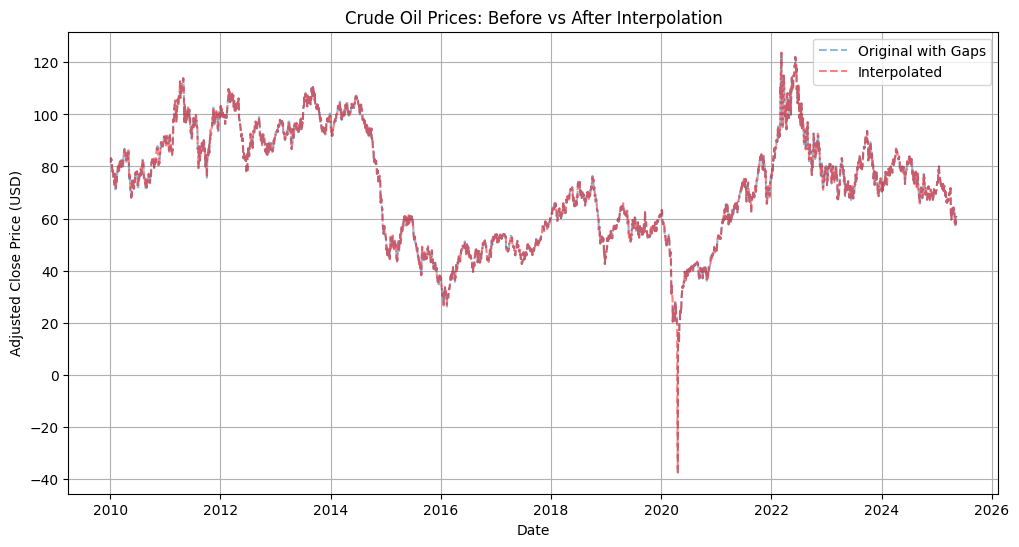

In [10]:
# Visualize the effect of interpolation
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Adj Close'], label='Original with Gaps', alpha=0.5, linestyle='--')
plt.plot(df_filled.index, df_filled['Adj Close'], label='Interpolated', color='red', alpha=0.5, linestyle='--')
plt.title('Crude Oil Prices: Before vs After Interpolation')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

Here, I allocate 70% for training, 15% for validation, and 15% for testing.

In [11]:
# Calculate split sizes
train_size = int(len(df_filled) * 0.7)
val_size = int(len(df_filled) * 0.15)
test_size = len(df_filled) - train_size - val_size

In [12]:
# Perform temporal split
train_data = df_filled.iloc[:train_size]
val_data = df_filled.iloc[train_size:train_size + val_size]
test_data = df_filled.iloc[train_size + val_size:]

In [13]:
# Print split details with date ranges
print(f"Training data: {len(train_data)} days ({train_data.index[0]} to {train_data.index[-1]})")
print(f"Validation data: {len(val_data)} days ({val_data.index[0]} to {val_data.index[-1]})")
print(f"Test data: {len(test_data)} days ({test_data.index[0]} to {test_data.index[-1]})")

Training data: 2702 days (2010-01-04 00:00:00 to 2020-09-29 00:00:00)
Validation data: 579 days (2020-09-30 00:00:00 to 2023-01-18 00:00:00)
Test data: 580 days (2023-01-19 00:00:00 to 2025-05-09 00:00:00)


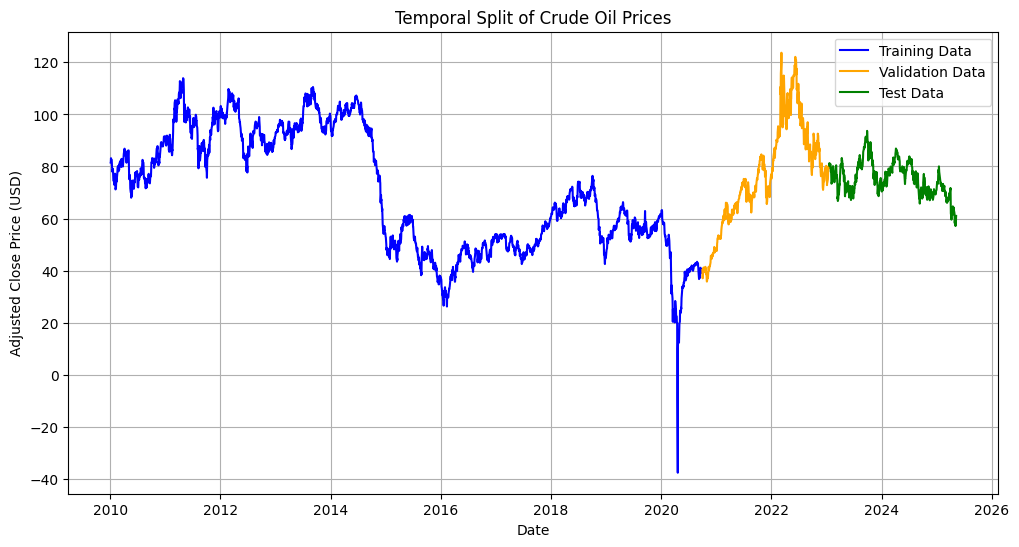

In [14]:
# Visualize the splits
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Adj Close'], label='Training Data', color='blue')
plt.plot(val_data.index, val_data['Adj Close'], label='Validation Data', color='orange')
plt.plot(test_data.index, test_data['Adj Close'], label='Test Data', color='green')
plt.title('Temporal Split of Crude Oil Prices')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

I apply `MinMaxScaler` to scale the data to a \[0, 1\] range to improve model training stability.  

In [15]:
# Initialize and apply the scaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_filled[['Adj Close']].values)

# Re-split the scaled data
train_data_scaled = scaled_data[:train_size]
val_data_scaled = scaled_data[train_size:train_size + val_size]
test_data_scaled = scaled_data[train_size + val_size:]

# Show min/max of original and scaled data for verification
print(f"Original data min: {df_filled['Adj Close'].min()}, max: {df_filled['Adj Close'].max()}")
print(f"Scaled data min: {scaled_data.min()}, max: {scaled_data.max()}")
print("\nSample of scaled training data (first 5 values):")
print(train_data_scaled[:5].flatten())

Original data min: Ticker
CL=F   -37.630001
dtype: float64, max: Ticker
CL=F    123.699997
dtype: float64
Scaled data min: 0.0, max: 1.0

Sample of scaled training data (first 5 values):
[0.73848636 0.74009793 0.7488378  0.74561462 0.74617246]


In [16]:
# Define sequence length and create sequences
seq_length = 60

In [17]:
# Generate training sequences
X_train, y_train = create_sequences(train_data_scaled, seq_length)
# Generate sequences for each split
X_train, y_train = create_sequences(train_data_scaled, seq_length)
X_val, y_val = create_sequences(val_data_scaled, seq_length)
X_test, y_test = create_sequences(test_data_scaled, seq_length)

# Select the first sequence and its target for plotting
sample_sequence = X_train[0].flatten()  # First 60-day sequence
sample_target = y_train[0][0]          # Corresponding target (61st day)
sample_dates = df_filled.index[:seq_length].to_list() + [df_filled.index[seq_length]]

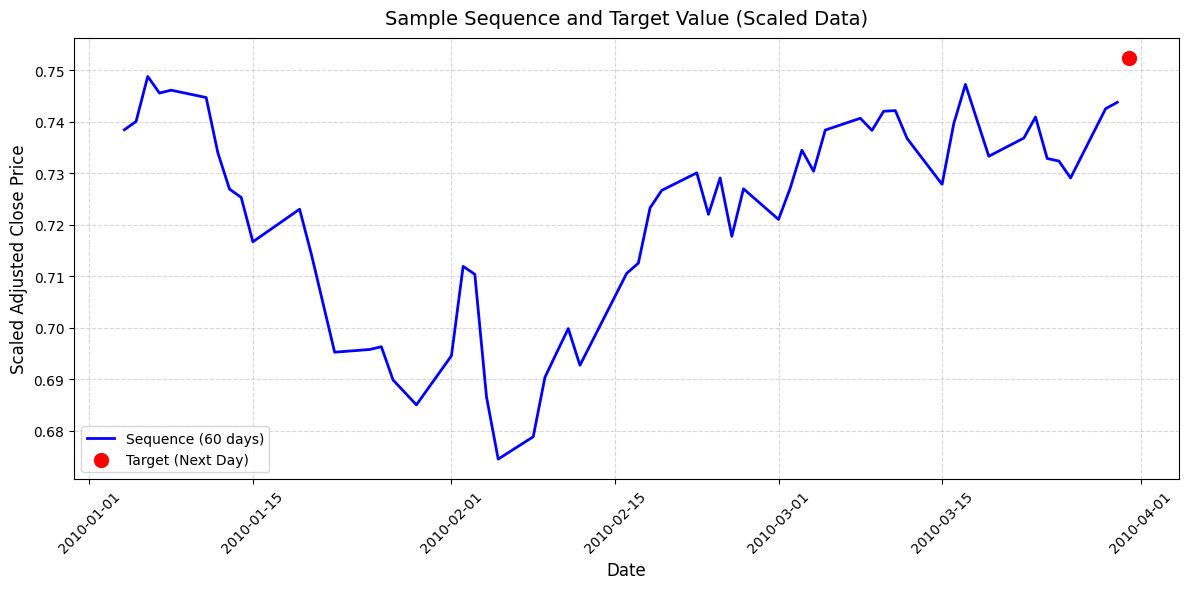


Sample sequence (first 5 scaled values): [0.73848636 0.74009793 0.7488378  0.74561462 0.74617246]
Target (scaled): 0.7524

Sample sequence (first 5 original values): [81.51000214 81.76999664 83.18000031 82.66000366 82.75      ]
Target (original): 83.76


In [18]:
# Plot the sequence and target
plt.figure(figsize=(12, 6))
plt.plot(sample_dates[:seq_length], sample_sequence, label='Sequence (60 days)', color='blue', linewidth=2)
plt.scatter(sample_dates[seq_length], sample_target, color='red', s=100, label='Target (Next Day)', zorder=5)
plt.title('Sample Sequence and Target Value (Scaled Data)', fontsize=14, pad=10)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Scaled Adjusted Close Price', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Optional: Show the sequence and target in original scale for context
sequence_orig = scaler.inverse_transform(sample_sequence.reshape(-1, 1)).flatten()
target_orig = scaler.inverse_transform([[sample_target]])[0][0]
print("\nSample sequence (first 5 scaled values):", sample_sequence[:5])
print(f"Target (scaled): {sample_target:.4f}")
print("\nSample sequence (first 5 original values):", sequence_orig[:5])
print(f"Target (original): {target_orig:.2f}")

### Answer 1.2

In [19]:
# Hyperparameters
learning_rate = 0.001
units = 512

Building Simple RNN...

Training Simple RNN...


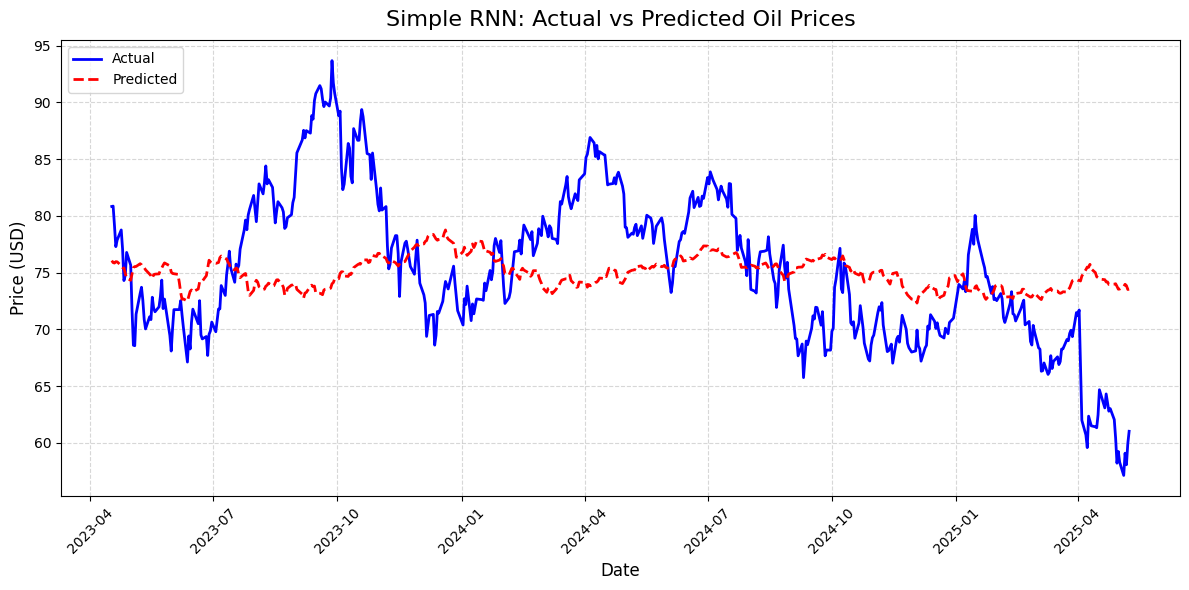

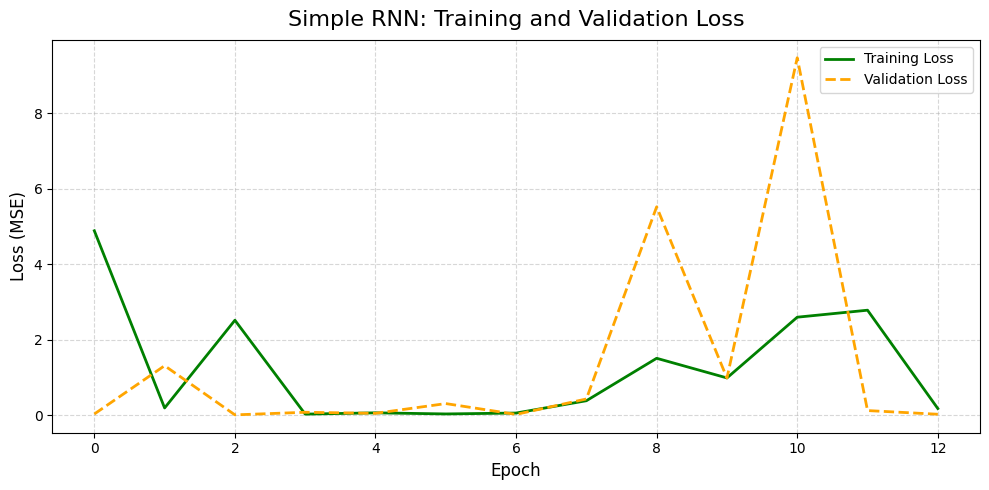

In [20]:
# Simple RNN
print("Building Simple RNN...")
rnn_model = Sequential([
    SimpleRNN(units, activation='tanh', return_sequences=True, input_shape=(seq_length, 1)),
    SimpleRNN(units, activation='tanh', return_sequences=False),
    Dense(25, activation='relu'),
    Dense(1)
])
rnn_model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
rnn_metrics, rnn_pred, rnn_history = train_evaluate_visualize(
    rnn_model, 'Simple RNN', X_train, y_train, X_val, y_val, X_test, y_test, 
    scaler, df_filled, train_size, val_size, seq_length
)

Building GRU...

Training GRU...


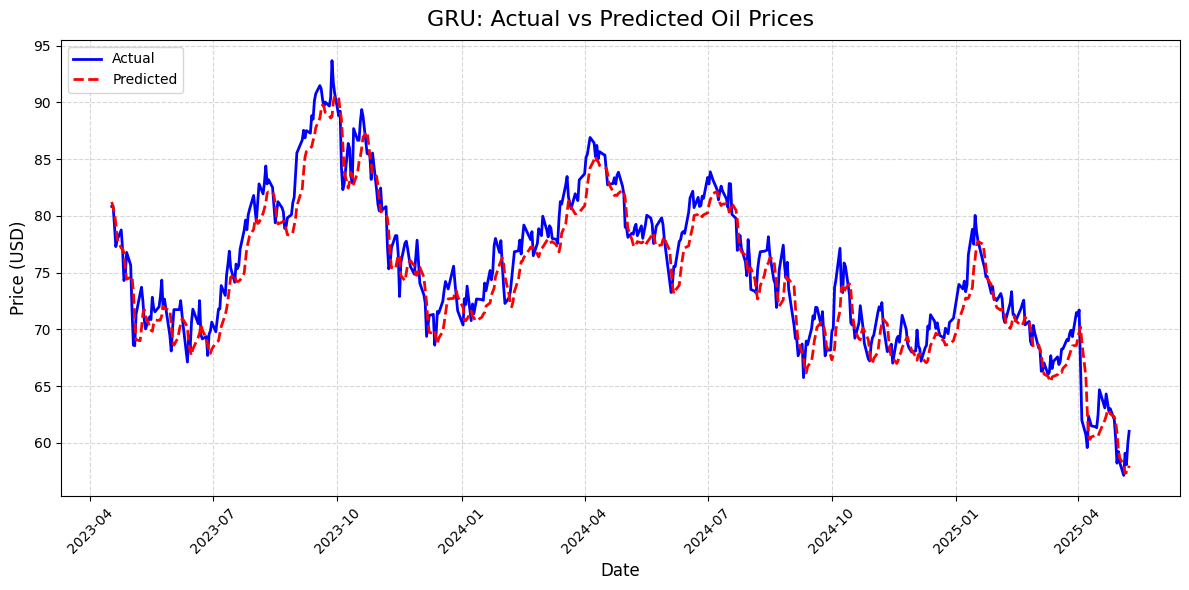

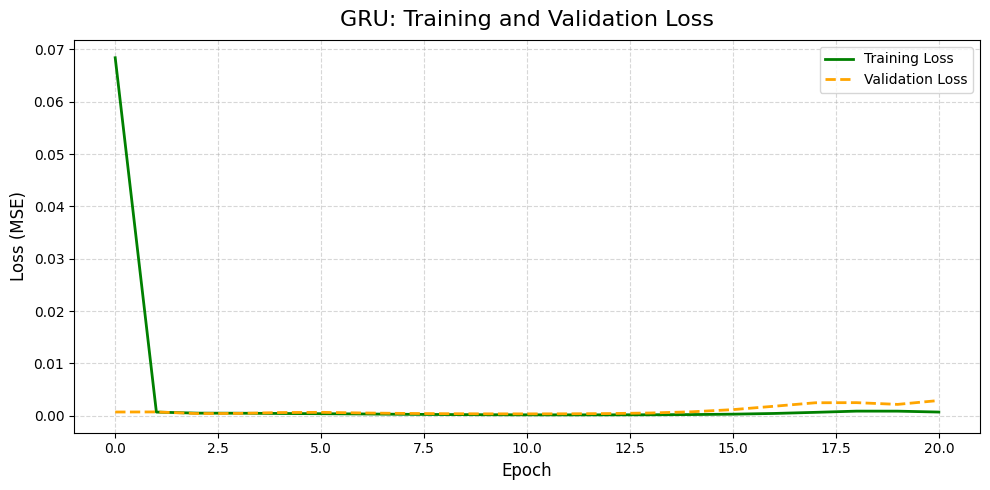

In [ ]:
# GRU
print("Building GRU...")
gru_model = Sequential([
    GRU(units, activation='tanh', return_sequences=True, input_shape=(seq_length, 1)),
    GRU(units, activation='tanh', return_sequences=False),
    Dense(25, activation='relu'),
    Dense(1)
])
gru_model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
gru_metrics, gru_pred, gru_history = train_evaluate_visualize(
    gru_model, 'GRU', X_train, y_train, X_val, y_val, X_test, y_test, 
    scaler, df_filled, train_size, val_size, seq_length
)

Building LSTM...

Training LSTM...


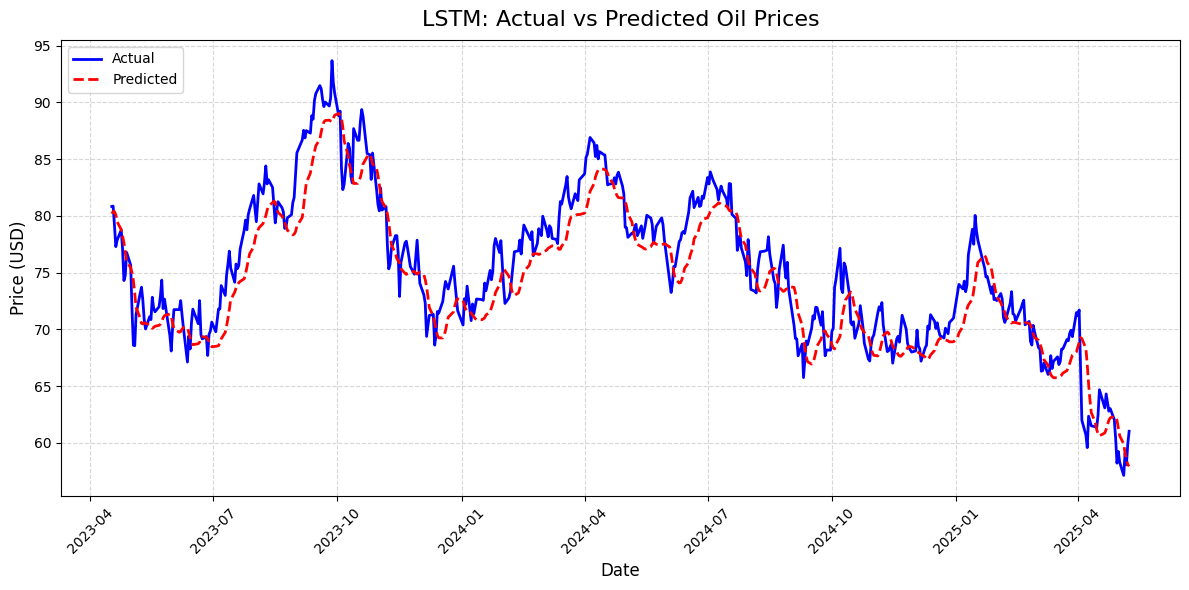

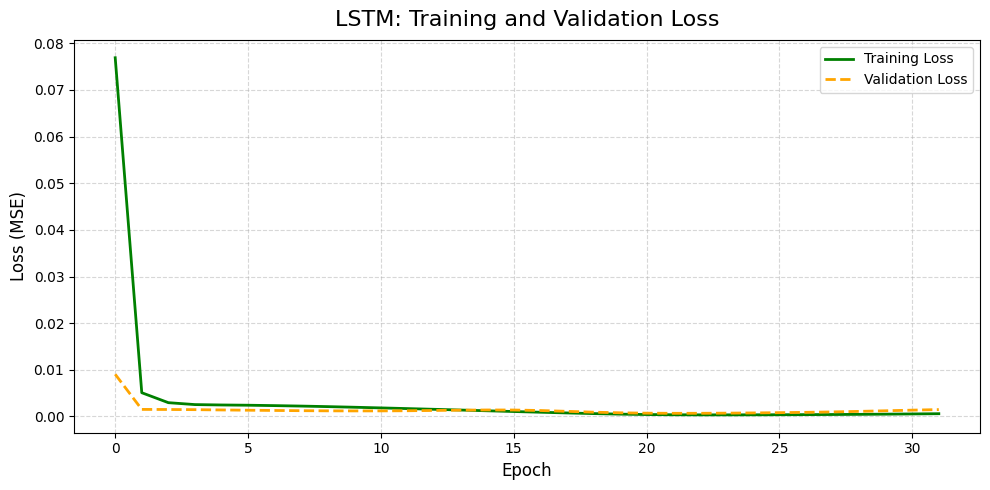

In [22]:
# LSTM
print("Building LSTM...")
lstm_model = Sequential([
    LSTM(units, activation='tanh', return_sequences=True, input_shape=(seq_length, 1)),
    LSTM(units, activation='tanh', return_sequences=False),
    Dense(25, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
lstm_metrics, lstm_pred, lstm_history = train_evaluate_visualize(
    lstm_model, 'LSTM', X_train, y_train, X_val, y_val, X_test, y_test, 
    scaler, df_filled, train_size, val_size, seq_length
)

Building Bi-LSTM...

Training Bi-LSTM...


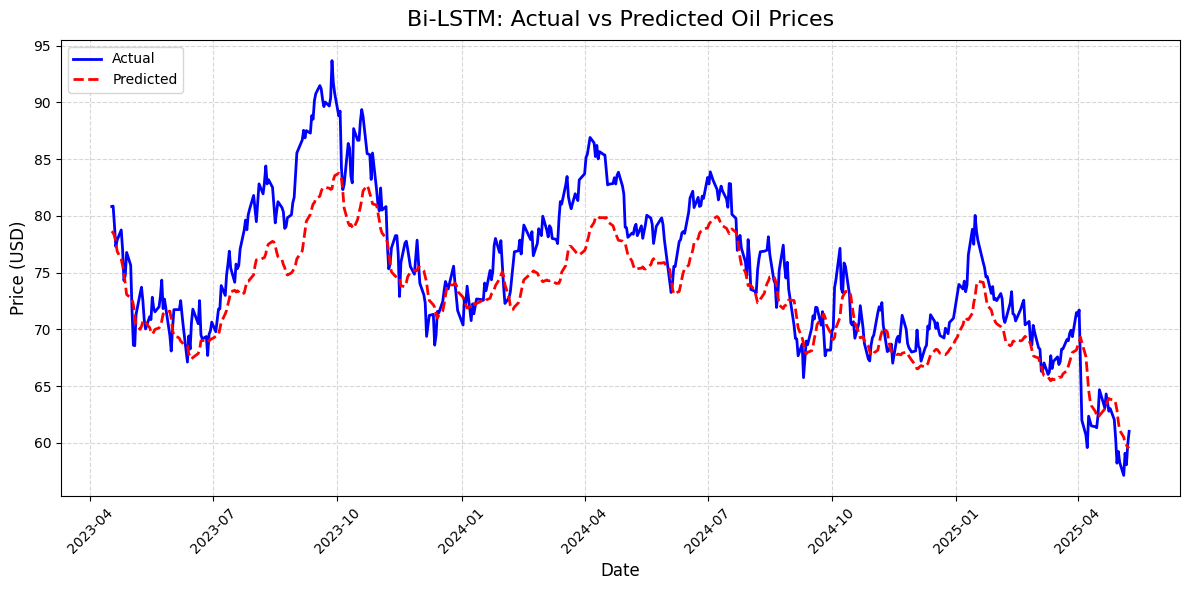

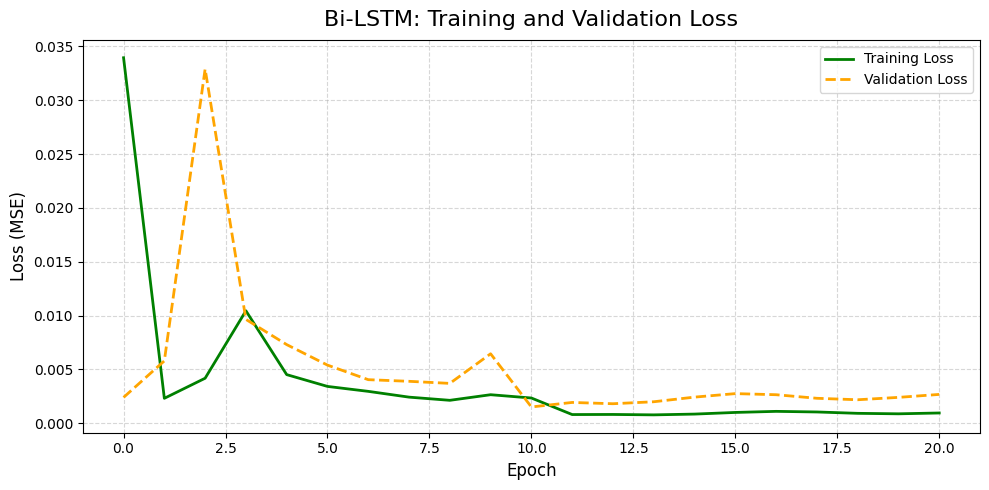

In [23]:
# Bi-LSTM
print("Building Bi-LSTM...")
bilstm_model = Sequential([
    Bidirectional(LSTM(512, activation='tanh', return_sequences=True), input_shape=(seq_length, 1)),
    Bidirectional(LSTM(512, activation='tanh', return_sequences=False)),
    Dense(25, activation='relu'),
    Dense(1)
])

bilstm_model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
bilstm_metrics, bilstm_pred, bilstm_history = train_evaluate_visualize(
    bilstm_model, 'Bi-LSTM', X_train, y_train, X_val, y_val, X_test, y_test, 
    scaler, df_filled, train_size, val_size, seq_length
)

- **MAPE (Mean Absolute Percentage Error):**  
  $$
  MAPE = \frac{100\%}{n} \sum_{i=1}^n \left| \frac{y_i - \hat{y}_i}{y_i} \right|
  $$  
  *Relative error in percentage; sensitive to small actual values.*


- **MAE (Mean Absolute Error):**  
  $$
  MAE = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|
  $$  
  *Average error in USD.*

- **RMSE (Root Mean Squared Error):**  
  $$
  RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}
  $$  
  *Square root of average squared errors.*


- **R-Squared ($R^2$):**  
  $$
  R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
  $$  
  *Goodness-of-fit; 1 indicates perfect prediction.*


In [24]:
# Compile metrics into a DataFrame
metrics_df = pd.DataFrame([rnn_metrics, gru_metrics, lstm_metrics, bilstm_metrics])

# Round values for readability
metrics_df = metrics_df.round({'MSE': 2, 'RMSE': 2, 'MAE': 2, 'MAPE': 2, '$R^2$': 3})

# Display formatted table
print("\nModel Performance Summary:")
display(metrics_df)

# Identify best model by RMSE
best_model = metrics_df.loc[metrics_df['RMSE'].idxmin(), 'Model']
print(f"\nBest model (lowest RMSE): {best_model}")


Model Performance Summary:


,Model,MSE,RMSE,MAE,MAPE,$R^2$
0,Simple RNN,44.40,6.66,5.35,7.12,-0.013
1,GRU,4.08,2.02,1.67,2.22,0.907
2,LSTM,6.71,2.59,2.12,2.81,0.847
3,Bi-LSTM,13.25,3.64,2.95,3.79,0.698



Best model (lowest RMSE): GRU


In [25]:
display(metrics_df.style.set_caption("Performance Metrics").set_table_styles([
    {'selector': 'caption', 'props': 'font-size:16px; font-weight:bold;'},
    {'selector': 'th', 'props': 'text-align:center;'},
    {'selector': 'td', 'props': 'text-align:center;'}
]))

,Model,MSE,RMSE,MAE,MAPE,$R^2$
0,Simple RNN,44.400000,6.660000,5.350000,7.120000,-0.013000
1,GRU,4.080000,2.020000,1.670000,2.220000,0.907000
2,LSTM,6.710000,2.590000,2.120000,2.810000,0.847000
3,Bi-LSTM,13.250000,3.640000,2.950000,3.790000,0.698000


<Figure size 1000x600 with 0 Axes>

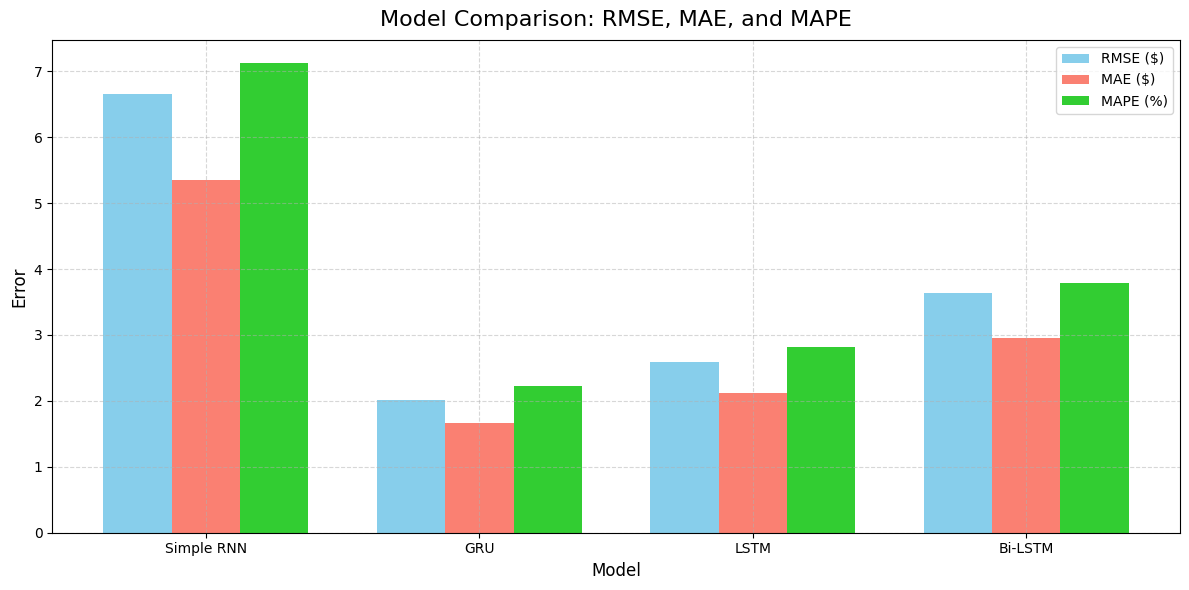

In [26]:
# Bar chart for RMSE and MAE comparison
plt.figure(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(metrics_df['Model']))
# Bar chart for RMSE, MAE, and MAPE comparison
plt.figure(figsize=(12, 6))
bar_width = 0.25  # Adjusted for three bars
index = np.arange(len(metrics_df['Model']))

# Plot bars for each metric
plt.bar(index, metrics_df['RMSE'], bar_width, label='RMSE ($)', color='skyblue')
plt.bar(index + bar_width, metrics_df['MAE'], bar_width, label='MAE ($)', color='salmon')
plt.bar(index + 2 * bar_width, metrics_df['MAPE'], bar_width, label='MAPE (%)', color='limegreen')

# Customize the plot
plt.xlabel('Model', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.title('Model Comparison: RMSE, MAE, and MAPE', fontsize=16, pad=10)
plt.xticks(index + bar_width, metrics_df['Model'], fontsize=10)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

### Results Analysis

GRU has the best performance, with the lowest errors and highest $R^2$. Its edge stems from its gating mechanisms—the update and reset gates—that manages temporal dependencies, handling vanishing gradient while it is not as computational expensive as the more complex structures.

Simple RNN’s has by far the worst performance which is showing why basic architectures fail with long-term patterns, like oil market cycles, indicating the need for more advanced models like GRU and LSTM. On the other hand Bi-LSTM’s has lower performance than LSTM and LSTM also prefomes worse than GRU, suggesting the extra complexity might not be necessary when unidirectional less complex model already captures the critical patterns and the extra complexity is just making model to overfit on training set.

**Important:**

While, I set the shuffle to false based on time-series training convention, shuffling the data can compensate the long memmory alzeimer of simple RNN quiet good. By randomly exposing the small patterns of data in each step, it leads to more robust learning for simple RNN. It also slightly increases error for more complex structures. One might consider this training method, if computational efficiency is more important than the perciseness for him/her.

In [ ]:
# Combined plot of all predictions
test_dates = df_filled.index[train_size + val_size + seq_length: 
                            train_size + val_size + seq_length + len(y_test)]
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test_orig, label='Actual', color='blue', linewidth=2.5)
plt.plot(test_dates, rnn_pred, label='Simple RNN', color='green', linestyle='--', alpha=0.7)
plt.plot(test_dates, gru_pred, label='GRU', color='red', linestyle='-.', alpha=0.7)
plt.plot(test_dates, lstm_pred, label='LSTM', color='purple', linestyle=':', alpha=0.7)
plt.plot(test_dates, bilstm_pred, label='Bi-LSTM', color='orange', linestyle='--', alpha=0.7)
plt.title('All Models: Actual vs Predicted Oil Prices', fontsize=16, pad=10)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=10, bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Answer 1.3

The **ARIMA (AutoRegressive Integrated Moving Average)** model is a classical statistical method for time series forecasting. It is defined by three parameters: $(p, d, q)$, where:

- $p$: Number of lag observations (AutoRegressive terms).
- $d$: Number of times the data is differenced to make it stationary (Integrated terms).
- $q$: Size of the moving average window (Moving Average terms).

The model assumes a linear relationship between past values and errors to predict future values. Mathematically, an ARIMA model can be expressed as:

$$
y_t' = c + \phi_1 y_{t-1}' + \phi_2 y_{t-2}' + \cdots + \phi_p y_{t-p}' + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \cdots + \theta_q \epsilon_{t-q} + \epsilon_t
$$

- $y_t'$: Differenced time series (if $d > 0$).
- $\phi_i$: AR coefficients.
- $\theta_j$: MA coefficients.
- $\epsilon_t$: White noise error term.

SARIMA (Seasonal ARIMA) extends ARIMA by adding seasonal components $(P, D, Q, s)$ to model time series with both non-seasonal and seasonal patterns, where $s$ is the seasonal period.

ADF test on training data:
Test Statistic            -1.455156
p-value                    0.555567
#Lags Used                 8.000000
Observations            2693.000000
Critical Value (1%)       -3.432781
Critical Value (5%)       -2.862614
Critical Value (10%)      -2.567342
dtype: float64
Selected d = 1

Best ARIMA order: (4, 1, 2) (AIC=10760.2)


Comparison Table:


,MSE,RMSE,MAE,MAPE,R2
ARIMA,1558.075,39.472,36.647,45.97,-6.154


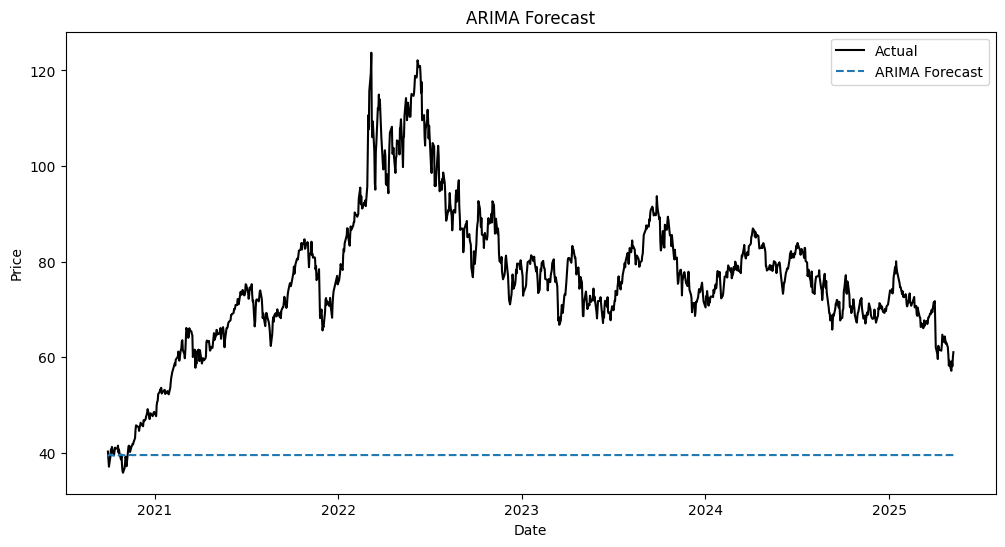

In [27]:
series = df_filled['Adj Close']
metrics_arima, idx_arima, true_arima, pred_arima = forecast_arima(series, train_size)

# Results Table
results = pd.DataFrame([metrics_arima], index=['ARIMA'])
print("\nComparison Table:")
display(results.round(3))

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(idx_arima, true_arima, label='Actual', color='black')
plt.plot(idx_arima, pred_arima, label='ARIMA Forecast', linestyle='--')
plt.title('ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

#### *Let's try whether rolling forecast with helps ARIMA or not*

In [43]:
def adf_test(series):
    result = adfuller(series.dropna(), autolag='AIC')
    return result[1] <= 0.05

In [44]:
def rolling_forecast_arima(series, initial_train_size, horizon=1, max_rolls=None,
                                      p_range=range(0, 3), q_range=range(0, 3)):
    actuals, preds, dates = [], [], []
    end = len(series) - horizon
    roll_range = range(initial_train_size, end)
    if max_rolls:
        roll_range = roll_range[:max_rolls]
        
    for t in roll_range:
        train = series.iloc[:t]
        test = series.iloc[t:t+horizon]

        d = 0 if adf_test(train) else 1
        best_aic = np.inf
        best_order = None

        for p in p_range:
            for q in q_range:
                model = ARIMA(train, order=(p, d, q)).fit()
                if model.aic < best_aic:
                    best_aic = model.aic
                    best_order = (p, d, q)

        final_model = ARIMA(train, order=best_order).fit()
        forecast = final_model.forecast(steps=horizon)

        preds.append(forecast.iloc[-1])
        actuals.append(test.iloc[-1])
        dates.append(test.index[-1])

    result_df = pd.DataFrame({
        'Date': dates,
        'Actual': actuals,
        'Forecast': preds
    }).set_index('Date')

    metrics = evaluate_forecast(np.array(actuals), np.array(preds))
    return result_df, metrics


In [45]:
rolling_df, rolling_metrics = rolling_forecast_arima(
    series=df_filled['Adj Close'],
    initial_train_size=train_size + val_size,
    horizon=1,
    max_rolls=100,
    p_range=range(0, 3),
    q_range=range(0, 3)
)

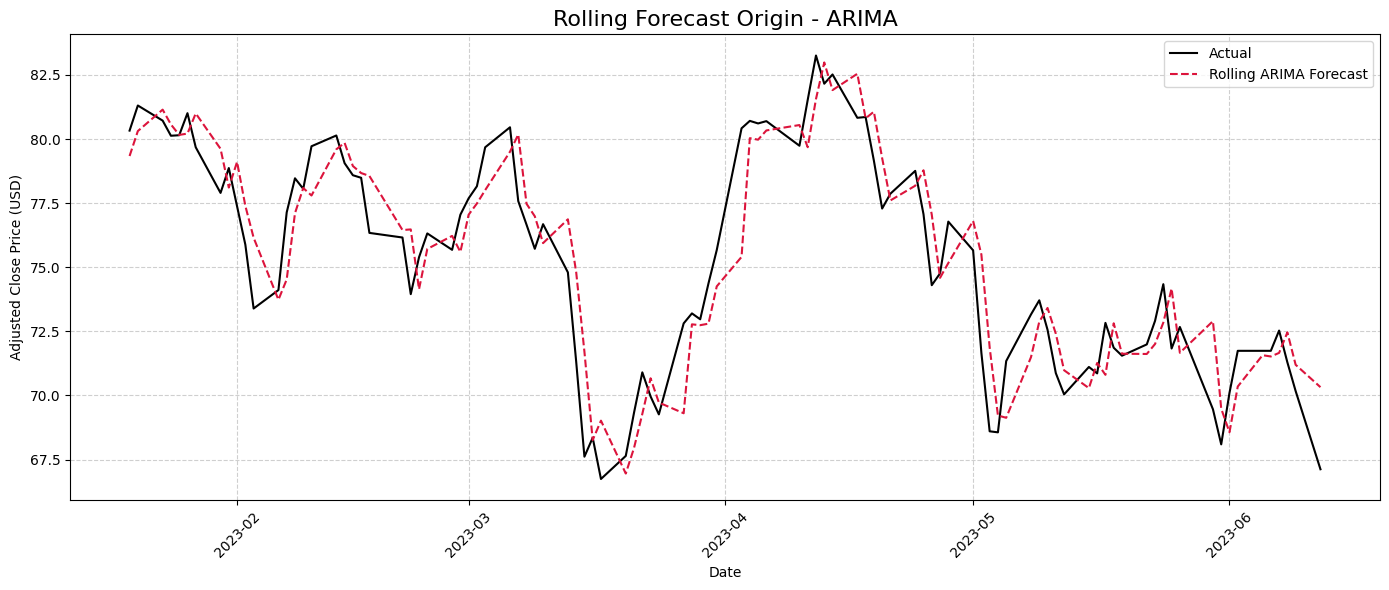

In [46]:
plt.figure(figsize=(14, 6))
plt.plot(rolling_df.index, rolling_df['Actual'], label='Actual', color='black')
plt.plot(rolling_df.index, rolling_df['Forecast'], label='Rolling ARIMA Forecast', color='crimson', linestyle='--')
plt.title('Rolling Forecast Origin - ARIMA', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [47]:
print(rolling_metrics)

{'MSE': 2.7062430240897353, 'RMSE': 1.6450662673855225, 'MAE': 1.3094185704184156, 'MAPE': 6.390373889771865, 'R2': 0.8480271053583228}


## Question 2 - Predicting Suicidal Ideation on Social Media

#### Introduction

>   The goal of this exercise is to detect suicidal thoughts in a set of Twitter data.
>   The referenced article examined several classical and deep-learning methods and found that deep-learning models perform best.
>   
>   Using the data supplied for this assignment (tweet text + suicide/non-suicide label), you must evaluate three deep-learning models:
>   
>   * **LSTM**
>   * **2-layer LSTM**
>   * **CNN + 2-layer LSTM**
>   
>   Where the article omits hyper-parameters (learning rate, neurons, …) you may choose reasonable values.

#### 2-1 Data Pre-Processing (30 points)


>   Carry out **all** preprocessing steps stated in the article—lemmatization, stop-word removal, deleting punctuation, removing repeated letters, etc.—your processed data is expected to look like:
>   
>   **Text 1**
>   
>   > `my life is meaningless i just want to end my life so badly my life is completely empty and i dont want to have to create meaning in it creating meaning is pain how long will i hold back the urge to run my car head ﬁrst into the next person coming the opposite way when will i stop feeling jealous of tragic characters like gomer pile for the swift end they were able to bring to their lives`
>   
>   **Text 2**
>   
>   > `life meaningless want end life badly life completely empty dont want create meaning creating  meaning  pain  long  hold  back  urge  run  car  head  ﬁrst  next  person  coming opposite way stop feeling jealous tragic character like gomer pile swift end able bring life`


#### 2-2 Building the Embedding Matrix (10 points)

>   In this section, as stated in the referenced article, it is necessary to use the **pre-trained Word2Vec model** to construct the embedding matrix. The embedding matrix is a method for converting complex data (like words, images, or users) into compact numerical vectors that preserve their semantic meanings and relationships. Compared to simple methods like **One-Hot Encoding**, it is significantly smaller in size and more precise. Briefly describe the characteristics and advantages of these embeddings in your report.
>
>   The **Word2Vec** algorithm in natural language processing converts words into fixed-dimensional numerical vectors such that semantic similarities between words are preserved in this numeric space. For example, words like “doctor” and “nurse” are placed closer together than “doctor” and “printer”, reflecting their semantic similarity.
?
>   Word2Vec has made it possible to learn relationships among words using basic vocabulary in many NLP tasks such as **machine translation**, **sentiment analysis**, and **question answering**.
>   
>   *Bonus (5 pts):* Investigate other popular embedding methods and use them.

#### 2-3 Training Deep-Learning Models (50 points)


>   Design and train the three models—**LSTM, 2-layer LSTM, and CNN + 2-layer LSTM**—with the pre-processed data. A short description for each model is provided:
>   
>   * **Long Short-Term Memory (LSTM)** - an advanced RNN designed to capture long-distance dependencies via memory cells and gates.
>   * **2-layer LSTM** - two stacked LSTM layers; the deeper structure allows the model to learn more complex patterns.
>   * **CNN + 2-layer LSTM** - first a CNN extracts local features from text, then a two-layer LSTM analyses temporal dependencies.
>   
>   *Note:* You may hit a dimensionality error when building **CNN + 2-layer LSTM**; inserting a **Reshape** layer resolves it. Other solutions exist; see *[source 1](https://colah.github.io/posts/2015-08-Understanding-LSTMs/?utm_source=chatgpt.com)*, *[source 2](https://machinelearningmastery.com/stacked-long-short-term-memory-networks/)*, or *[source 3](https://www.analyticsvidhya.com/blog/2021/06/lstm-for-text-classification/)*.
>   

#### 2-4 Results and Analysis (10 points)

>   
>   Plot **accuracy and loss versus epochs** for the three models, analyse convergence, detect under- or over-fitting, and discuss:
>   
>   * Which model achieved the highest validation accuracy.
>   * Which converged fastest.
>   * How each performed on unseen data.

## Answer 2

### Prerequisits

In [103]:
# System & Warning Control
import os
import warnings
warnings.filterwarnings("ignore")

# Data Handling and Text Processing
import pandas as pd
import numpy as np
import re
import nltk

# Download necessary NLTK data
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Deep Learning & Model Utilities
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Reshape, Flatten, RepeatVector
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical


# Pre-trained Embedding (Word2Vec)
import gensim.downloader as api
from gensim.models import KeyedVectors

# Machine Learning Utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
import random
import tensorflow as tf
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


### Functions

In [50]:
def plot_history(history, title="Model Accuracy & Loss"):
    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [51]:
def compare_histories(histories, labels):
    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    for hist, label in zip(histories, labels):
        plt.plot(hist.history['val_accuracy'], label=f'{label}')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    for hist, label in zip(histories, labels):
        plt.plot(hist.history['val_loss'], label=f'{label}')
    plt.title('Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [52]:
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 3. Remove @mentions (e.g., @username → removed completely)
    text = re.sub(r'@\w+', '', text)

    # 4. Remove punctuation and non-alphabetic characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 5. Collapse multiple spaces into one, trim ends
    text = re.sub(r'\s+', ' ', text).strip()

    # 6. Tokenize
    words = word_tokenize(text)

    # 7. Normalize repeated letters: e.g., "soooo" → "so"
    words = [re.sub(r'(.)\1{2,}', r'\1', word) for word in words]

    # 8. Remove stopwords
    words = [word for word in words if word not in stop_words]

    # 9. Lemmatize tokens
    words = [lemmatizer.lemmatize(word) for word in words]

    # 9. Collapse only consecutive duplicates (e.g. "life life pain" → "life pain")
    collapsed = []
    prev = None
    for w in words:
        if w != prev:
            collapsed.append(w)
        prev = w

    return ' '.join(collapsed)

In [60]:
def load_word2vec_model():
    if os.path.exists(word2vec_path):
        print("Loading Word2Vec from disk...")
        return KeyedVectors.load(word2vec_path, mmap='r')
    else:
        print("Downloading GoogleNews Word2Vec model ...")
        model = api.load("word2vec-google-news-300") 
        model.save(word2vec_path)
        return model
    
def load_glove_model():
    if os.path.exists(glove_path):
        print("Loading Word2Vec from disk...")
        return KeyedVectors.load(glove_path, mmap='r')
    else:
        print("Downloading GloVe model ...")
        model = api.load("glove-wiki-gigaword-100") 
        model.save(glove_path)
        return model

### Answer 2.1

In [61]:
# Load the dataset
data = pd.read_csv('twitter-suicidal_data.csv')

# Preview
print("Dataset Shape:", data.shape)
print("Columns:", data.columns.tolist())
print("\nSample Rows:")
display(data.head(3))

print("\nMissing values:")
print(data.isnull().sum())

Dataset Shape: (9119, 2)
Columns: ['tweet', 'intention']

Sample Rows:


,tweet,intention
0,my life is meaningless i just want to end my l...,1
1,muttering i wanna die to myself daily for a fe...,1
2,work slave i really feel like my only purpose ...,1



Missing values:
tweet        0
intention    0
dtype: int64


In [62]:
# Initialize preprocessing tools augmented with common Twitter tokens
stop_words = set(stopwords.words('english'))
extra = {
  # Retweets & HTML
  'rt','amp','via','gt','lt',
  # URL fragments
  'tco','bitly','co','com','org',
  # Mentions
  'username','user'
}
stop_words |= extra
lemmatizer = WordNetLemmatizer()

In [63]:
# Apply preprocessing to the tweet column
data['processed_tweet'] = data['tweet'].apply(preprocess_text)

# Show processed vs original
for i, row in data.head(3).iterrows():
    print(f"\n Row {i}")
    print("Original Tweet:\n", row['tweet'])
    print("Processed Tweet:\n", row['processed_tweet'])



 Row 0
Original Tweet:
 my life is meaningless i just want to end my life so badly my life is completely empty and i dont want to have to create meaning in it creating meaning is pain how long will i hold back the urge to run my car head first into the next person coming the opposite way when will i stop feeling jealous of tragic characters like gomer pile for the swift end they were able to bring to their lives
Processed Tweet:
 life meaningless want end life badly life completely empty dont want create meaning creating meaning pain long hold back urge run car head first next person coming opposite way stop feeling jealous tragic character like gomer pile swift end able bring life

 Row 1
Original Tweet:
 muttering i wanna die to myself daily for a few months now i feel worthless shes my soulmate i cant live in this horrible world without her i am so lonely i wish i could just turn off the part of my brain that feels 
Processed Tweet:
 muttering wan na die daily month feel worthless 

In [ ]:
# Initialize tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(data['processed_tweet'])

# Convert text to sequences and pad them
sequences = tokenizer.texts_to_sequences(data['processed_tweet'])
MAX_LEN = 50  # reasonable default, can tune later
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post')

# Labels
y = data['intention'].values

# Vocabulary size
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1  # +1 for padding index 0

### Answer 2.2

The `Word2Vec` embedding matrix represents each word as a dense, low-dimensional vector that captures both semantic and syntactic information. Unlike sparse representations like `one-hot encoding`, `Word2Vec` places semantically similar words close together in the vector space, allowing models to generalize and reason over language more effectively.

In [ ]:
# Load Pre-trained Word2Vec Model
word2vec_path = 'word2vec-google-news-300.model'
word2vec_model = load_word2vec_model()
glove_path = 'glove-wiki-gigaword-100.model'
glove = load_glove_model()

Loading Word2Vec from disk...
[==================================================] 100.0% 128.1/128.1MB downloaded


In [ ]:
# Define Embedding Parameters
embedding_dim = 300  # GoogleNews vectors are 300-dimensional
vocab_size = len(word_index) + 1  # +1 for padding token

# Initialize Embedding Matrix
embedding_matrix = np.zeros((vocab_size, embedding_dim), dtype=np.float32)

# Fill Embedding Matrix
# Attempt to match each word in different casing formats
for word, idx in word_index.items():
    if word in word2vec_model:
        embedding_matrix[idx] = word2vec_model[word]
    elif word.capitalize() in word2vec_model:
        embedding_matrix[idx] = word2vec_model[word.capitalize()]
    elif word.upper() in word2vec_model:
        embedding_matrix[idx] = word2vec_model[word.upper()]
    # If not found, leave the row as zero (out ouf vocabulary)

# Compute Vocabulary Coverage
covered = np.count_nonzero(np.any(embedding_matrix, axis=1))
coverage_pct = covered / vocab_size * 100
print(f'Embedding Coverage: {covered}/{vocab_size} words ({coverage_pct:.2f}%)')

Embedding Coverage: 15206/21732 words (69.97%)


Embedding methods generally fall into three categories:



#### **1. Static Word-Level Embeddings** *(Word2Vec, GloVe, fastText, LexVec, ConceptNet Numberbatch):*


These embeddings produce **one fixed vector per word**, regardless of context, assuming a word’s meaning can be understood by the words around it. While they share this core idea, each differs in how they derive meaning from word relationships.



* **Word2Vec:**
  Learns embeddings by looking at local context, i.e. words appearing together. For instance, "apple" often appears near words like "sweet," "crisp," or "bite," positioning it close to related terms like "banana."
  A famous example is `king - man + woman ≈ queen`. Word2Vec recognizes this because "king" and "queen" share contexts like "throne" and "palace," but differ in gendered usage ("he" versus "she"). It further refines understanding through **negative sampling**, contrasting valid word pairs with random, unrelated pairs to sharpen semantic accuracy.



* **GloVe:**
  Instead of focusing only on local context, GloVe takes a global perspective by analyzing how frequently words co-occur across the entire corpus. It finds patterns like "ice" frequently appearing with "cold" but rarely with "hot." Similarly, "king" and "queen" naturally emerge close together through common contexts like "royalty," but clearly separate due to masculine or feminine associations. GloVe’s global approach gives it a broad, nuanced understanding of word meanings.



* **fastText:**
  Builds on Word2Vec by including embeddings for smaller word segments (like "app," "ppl," from "apple"), making it highly effective at handling misspelled or rare words ("amazinng"). The famous analogy `king - man + woman ≈ queen` emerges strongly, as fastText captures meaningful subword patterns ("ing" in "king") combined with gender-specific contexts. This approach also lets fastText generalize easily to new variations or word forms.



* **LexVec:**
  Merges Word2Vec’s local precision with GloVe’s global co-occurrence analysis. LexVec carefully weighs meaningful word relationships, ignoring overly common associations. It captures nuanced semantic analogies like "king" versus "queen" by recognizing both shared (royalty) and distinct (gender) contexts clearly, providing highly precise semantic vectors.



* **ConceptNet Numberbatch:**
  This method enriches traditional embeddings with structured human-curated knowledge from knowledge graphs. Instead of inferring solely from text, it explicitly incorporates facts—like "sparrow" is a type of "bird." The analogy `king - man + woman ≈ queen` becomes particularly effective because Numberbatch explicitly encodes gender differences and royal relationships from structured knowledge, creating highly accurate semantic embeddings.



#### **2. Contextual Word Embeddings** *(ELMo, BERT):*


Unlike static embeddings, contextual embeddings create **different vectors for the same word** based on its sentence context.


* **ELMo:**
  Uses bi-directional LSTM models to understand how context shapes word meaning. It sees the word "crane" differently when it refers to a bird versus construction machinery, dynamically adapting vectors based on the sentence. The analogy "king" → "queen" arises naturally when shifting contexts from masculine ("he," "his") to feminine ("she," "her"). Although powerful at capturing context, ELMo can be slower due to sequential computations.



* **BERT:**
  Uses Transformers to let words simultaneously influence each other, capturing complex relationships efficiently. It easily distinguishes meanings like "bank" (financial or riverside) based entirely on sentence context. Similarly, subtle analogies like `king - man + woman ≈ queen` emerge intuitively, as BERT notes shifts from masculine to feminine contexts. While computationally intensive, BERT’s deep contextual understanding significantly boosts NLP performance across numerous tasks.


#### **3. Sentence-Level Embeddings** *(SBERT, USE):*


These embeddings provide **one fixed vector per sentence or phrase**, capturing holistic sentence meanings—useful for semantic similarity tasks or paraphrase detection.


* **Sentence-BERT (SBERT):**
  Specifically trained to produce sentence-level embeddings, it clusters semantically related sentences ("What’s the weather like?" and "Will it rain today?") and separates sentences with similar words but different meanings ("deposit money at the bank" vs "sit by the river bank"). SBERT naturally captures sentence-level analogies—"He is king" closely matches "She is queen," differing mainly by gender. It remains computationally demanding but efficient for semantic similarity searches.



* **Universal Sentence Encoder (USE):**
  Generates useful sentence embeddings out-of-the-box, either through averaging embeddings or via transformers, without additional training. It readily identifies semantic equivalence in conversational phrases ("How are you doing?" ≈ "What’s up?"). Sentence analogies ("He became king" ≈ "She became queen") emerge naturally due to structural similarity. USE prioritizes simplicity, efficiency, and speed, making it excellent for large-scale or real-time applications, even if it trades off minor accuracy compared to more computationally intensive models like SBERT.

In [ ]:
# Build GloVe matrix
glove_dim = 100
glove_matrix = np.zeros((vocab_size, glove_dim), dtype=np.float32)

for word, idx in word_index.items():
    if word in glove:
        glove_matrix[idx] = glove[word]
    elif word.capitalize() in glove:
        glove_matrix[idx] = glove[word.capitalize()]
    elif word.upper() in glove:
        glove_matrix[idx] = glove[word.upper()]

# Coverage comparison
glove_cov = np.count_nonzero(np.any(glove_matrix, axis=1))
w2v_cov   = np.count_nonzero(np.any(embedding_matrix, axis=1))
print(f"GloVe 100d coverage : {glove_cov}/{vocab_size} = {glove_cov/vocab_size:.2%}")
print(f"Word2Vec 300d coverage: {w2v_cov}/{vocab_size} = {w2v_cov/vocab_size:.2%}")


GloVe 100d coverage : 14387/21732 = 66.20%
Word2Vec 300d coverage: 15206/21732 = 69.97%


In [101]:
# Check the difference
# Cosine similarity
def cosine(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v) + 1e-9)

# Target words to analyze
keywords = ["suicide", "end", "life", "help", "kill", "myself", "cant", "commit"]

for word in keywords:
    print(f"\n{'Target Word:'} '{word}'")

    # Word2Vec
    print(f"Word2Vec Top-6:")
    try:
        for i, (sim_word, score) in enumerate(word2vec_model.most_similar(word, topn=6), 1):
            print(f"    {sim_word} ({score:.3f})")
    except KeyError:
        print("Not found in Word2Vec vocabulary.")

    # GloVe
    print(f"GloVe Top-6:")
    try:
        for i, (sim_word, score) in enumerate(glove.most_similar(word, topn=6), 1):
            print(f"    {sim_word} ({score:.3f})")
    except KeyError:
        print("Not found in GloVe vocabulary.")



Target Word: 'suicide'
Word2Vec Top-6:
    Suicide (0.694)
    suicides (0.663)
    commit_suicide (0.653)
    suicidal (0.634)
    belt_flak_vest (0.618)
    committing_suicide (0.585)
GloVe Top-6:
    attack (0.818)
    attacks (0.798)
    bombings (0.775)
    bombing (0.774)
    killed (0.746)
    bomb (0.729)

Target Word: 'end'
Word2Vec Top-6:
    ending (0.646)
    ends (0.591)
    beginning (0.530)
    ended (0.515)
    theend (0.472)
    endof (0.441)
GloVe Top-6:
    start (0.821)
    beginning (0.821)
    ending (0.817)
    next (0.817)
    this (0.802)
    last (0.800)

Target Word: 'life'
Word2Vec Top-6:
    lives (0.603)
    chiseled_burnished_refined (0.531)
    Interaction_enriches_your (0.496)
    Shanda_Interaction_enriches (0.495)
    Life (0.481)
    Fayaz_Wani_reports (0.464)
GloVe Top-6:
    lives (0.790)
    man (0.737)
    well (0.734)
    mind (0.733)
    years (0.732)
    own (0.731)

Target Word: 'help'
Word2Vec Top-6:
    helping (0.643)
    helps (0.589)
  

### Answer 2.3

In [104]:
train_ratio = 0.80
val_ratio   = 0.10
test_ratio  = 0.10

y_cat = to_categorical(y, num_classes=2)   # binary → one‑hot (n,2)

# First split off TRAIN vs TEMP (VAL+TEST)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_cat,
    train_size=train_ratio,
    random_state=42
)

# Now split TEMP into VAL and TEST
temp_val_fraction = val_ratio / (val_ratio + test_ratio)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    train_size=temp_val_fraction,
    random_state=42
)

In [105]:
# Build model
model_lstm = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=False,         # Use pretrained Word2Vec 
              mask_zero=True),         # Ignore padded zeros
    LSTM(128, dropout=0.5, recurrent_dropout=0.2),
    Dense(2, activation='softmax')
])

# Compile
model_lstm.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train
history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=0
)

# Identify best epoch
best_epoch = np.argmax(history_lstm.history['val_accuracy']) + 1
best_acc = np.max(history_lstm.history['val_accuracy'])
print(f"Best val-acc {best_acc:.4f} at epoch {best_epoch}")

Best val-acc 0.9342 at epoch 9


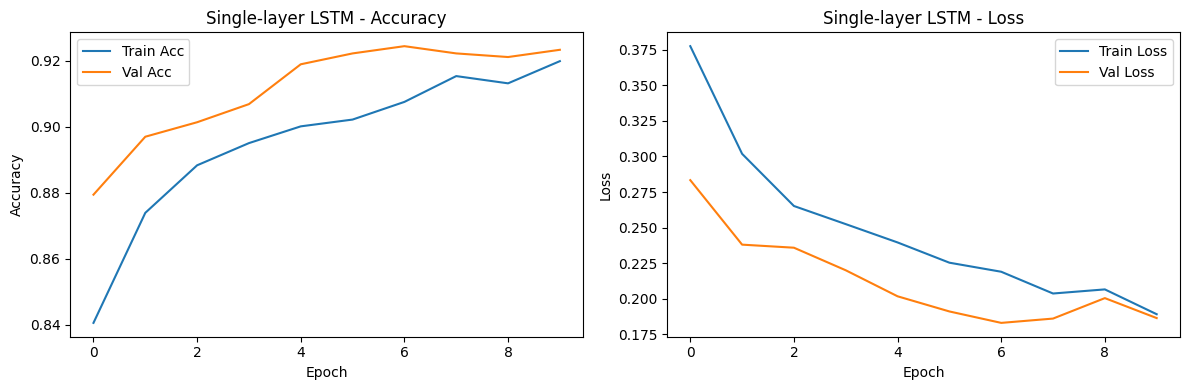

In [88]:
# Plot for Model 1
plot_history(history_lstm, title="Single-layer LSTM")

In [89]:
# Build 2-layer LSTM model
model_2lstm = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=False,
              mask_zero=True),
    LSTM(100, return_sequences=True, dropout=0.5, recurrent_dropout=0.2),
    LSTM(50, dropout=0.5, recurrent_dropout=0.2),
    Dense(2, activation='softmax')
])

# Compile model
model_2lstm.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

# Train model
history_2lstm = model_2lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],  # reuse same early stopping
    verbose=0
)

# Identify best epoch
best_epoch = np.argmax(history_lstm.history['val_accuracy']) + 1
best_acc = np.max(history_lstm.history['val_accuracy'])

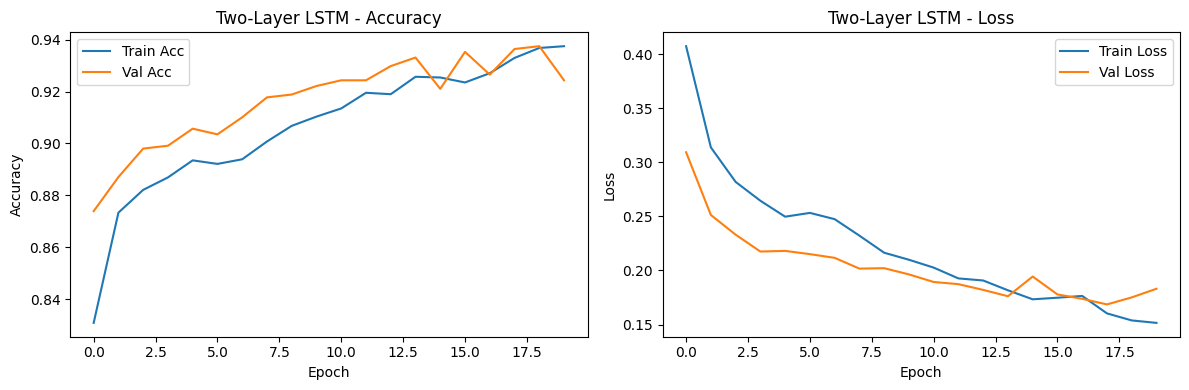

In [90]:
plot_history(history_2lstm, title="Two-Layer LSTM")

In [91]:
# CNN + 2-Layer LSTM Model
model_cnn_lstm = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=False,
              mask_zero=True),
    Conv1D(64, 3, padding='same', activation='relu'),
    MaxPooling1D(2),
    Flatten(),                              
    Dropout(0.5),
    RepeatVector(1),                        # wrap for LSTM input
    LSTM(100, return_sequences=True, dropout=0.5, recurrent_dropout=0.2),  
    LSTM(50, dropout=0.5, recurrent_dropout=0.2),                         
    Dense(2, activation='softmax')         
])

model_cnn_lstm.compile(optimizer='adam',
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

# Train
history_cnn_lstm = model_cnn_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=0
)

# Identify best epoch
best_epoch = np.argmax(history_cnn_lstm.history['val_accuracy']) + 1
best_acc   = np.max(history_cnn_lstm.history['val_accuracy'])
print(f"Best val-acc {best_acc:.4f} at epoch {best_epoch}")

Best val-acc 0.9265 at epoch 7


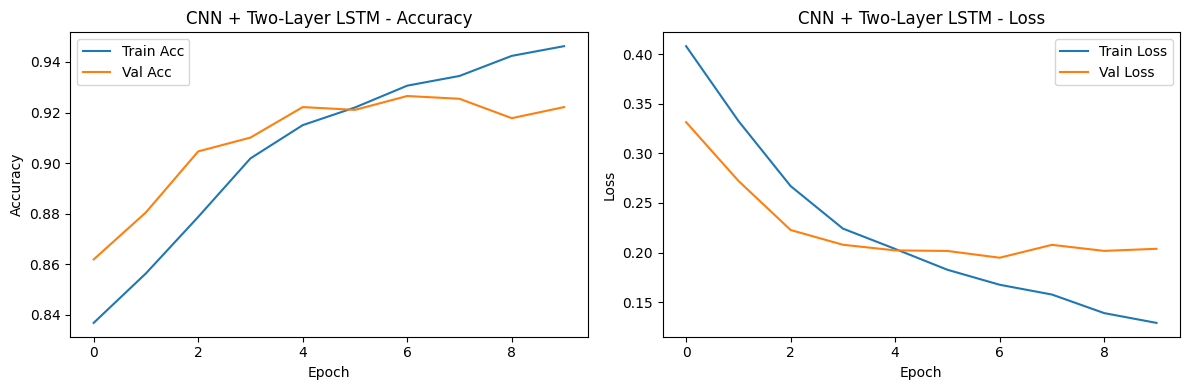

In [92]:
plot_history(history_cnn_lstm, title="CNN + Two-Layer LSTM")

### Answer 2.4

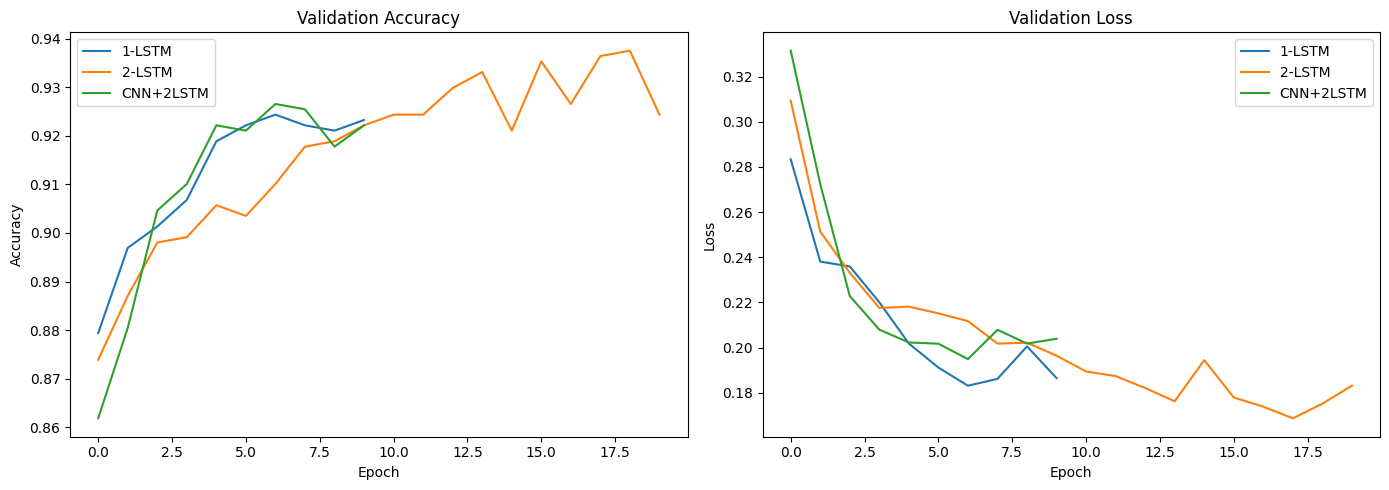

In [93]:
# Call function
compare_histories(
    [history_lstm, history_2lstm, history_cnn_lstm],
    ['1-LSTM', '2-LSTM', 'CNN+2LSTM']
)

Classification Report LSTM:
               precision    recall  f1-score   support

           0     0.9120    0.9464    0.9289       504
           1     0.9306    0.8873    0.9084       408

    accuracy                         0.9200       912
   macro avg     0.9213    0.9168    0.9187       912
weighted avg     0.9203    0.9200    0.9197       912



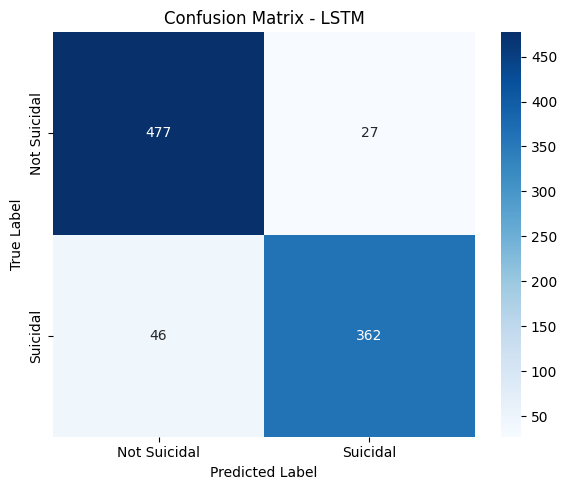

In [107]:
# Predict probabilities and class labels
y_pred_probs = model_lstm.predict(X_test, verbose=0)     # shape (n, 2)
y_pred = np.argmax(y_pred_probs, axis=1)                 # predicted class index
y_true = np.argmax(y_test, axis=1)                       # true class index

# Print classification report
report = classification_report(y_true, y_pred, digits=4)
print("Classification Report LSTM:\n", report)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Not Suicidal", "Suicidal"], 
            yticklabels=["Not Suicidal", "Suicidal"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - LSTM")
plt.tight_layout()
plt.show()

Classification Report 2LSTM:
               precision    recall  f1-score   support

           0     0.9165    0.9583    0.9370       504
           1     0.9455    0.8922    0.9180       408

    accuracy                         0.9287       912
   macro avg     0.9310    0.9252    0.9275       912
weighted avg     0.9295    0.9287    0.9285       912



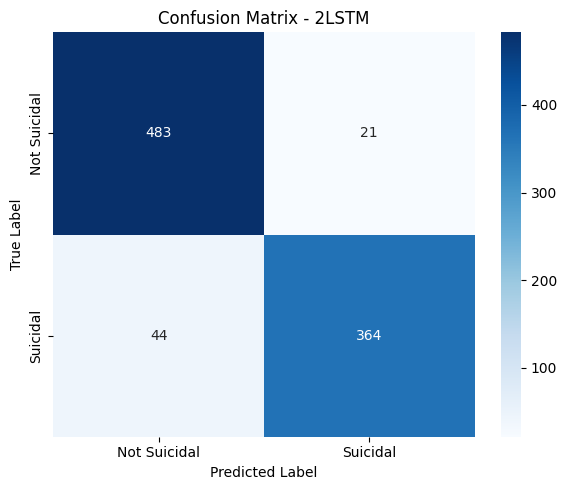

In [ ]:
# Predict probabilities and class labels
y_pred_probs = model_2lstm.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Print classification report
report = classification_report(y_true, y_pred, digits=4)
print("Classification Report 2LSTM:\n", report)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Not Suicidal", "Suicidal"], 
            yticklabels=["Not Suicidal", "Suicidal"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - 2LSTM")
plt.tight_layout()
plt.show()

Classification Report CNN + 2LSTM:
               precision    recall  f1-score   support

           0     0.8987    0.9683    0.9322       504
           1     0.9566    0.8652    0.9086       408

    accuracy                         0.9221       912
   macro avg     0.9277    0.9167    0.9204       912
weighted avg     0.9246    0.9221    0.9216       912



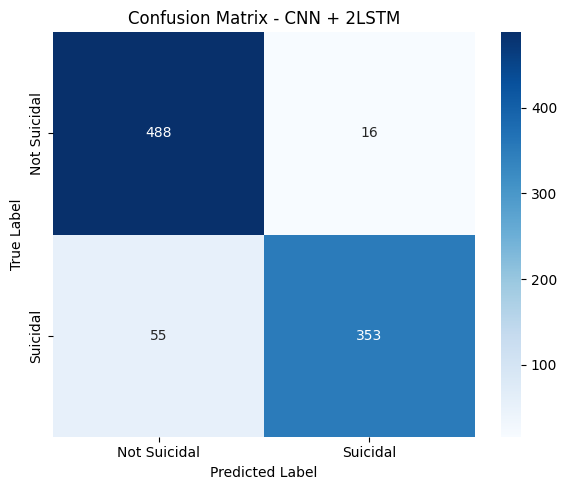

In [109]:
# Predict probabilities and class labels
y_pred_probs = model_cnn_lstm.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Print classification report
report = classification_report(y_true, y_pred, digits=4)
print("Classification Report CNN + 2LSTM:\n", report)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Not Suicidal", "Suicidal"], 
            yticklabels=["Not Suicidal", "Suicidal"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CNN + 2LSTM")
plt.tight_layout()
plt.show()

#### Results Analysis:

##### Model Comparison:


* **Single-layer LSTM**: Achieved a validation accuracy of around **92.7%** after 7-8 epochs, with a test accuracy of **92.0%**. While it learned quickly, it plateaued early, resulting in balanced but moderate error rates (46 false negatives vs. 27 false positives).


* **Two-layer LSTM** *(Best Performer)*: Clearly superior with a validation accuracy peaking at **93.8%** by epoch 18 and a test accuracy of **92.9%**. Its deeper structure allowed continuous improvement, capturing complex patterns more effectively, evidenced by balanced precision (94.6%) and recall (89.2%). The confusion matrix shows it made the fewest classification errors overall (44 false negatives vs. 21 false positives).


* **CNN + Two-layer LSTM**: Rapid initial convergence (90% accuracy by epoch 2), but quickly plateaued, reaching about **92.2%** validation accuracy. While overall performance was comparable to the single-layer LSTM, it had the lowest recall (86.5%) for suicidal tweets. This likely stems from the Flatten layer, which disrupts temporal dependencies by collapsing spatial dimensions before the LSTM layers, leading to a higher number of false negatives (55).


##### Convergence Behavior:


* The **CNN + 2-LSTM** had the fastest early improvement but then stagnated, hinting at slight overfitting after epoch 7.

* The **Two-layer LSTM** showed the most stable, continuous improvement, indicating robust generalization and optimal learning capacity.

##### Overfitting and Underfitting:

* No significant signs of severe overfitting or underfitting in any model.
* The CNN model showed a minor overfitting trend late in training (slight val-loss increase after epoch 7), but not critical.


##### Recommended Model:


* **Two-layer LSTM** is recommended as the best choice due to its highest accuracy, optimal balance between false positives and negatives, and strongest generalization performance.
* For simpler deployment scenarios where speed or resource constraints matter, the **single-layer LSTM** is a viable alternative with only a minor accuracy trade-off.


Overall, deeper sequential modeling (Two-layer LSTM) demonstrated clear superiority, aligning closely with the original paper’s findings about the benefits of stacked architectures for suicidal ideation detection on social media.
